<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW2 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>Desinged by Shaygan Adim</b></p>
</div>

---



*Full Name:*
Amirhosein Rezaei

*Student Number:*
401105989

## Homework Overview
In this homework, you will learn to implement, train, and evaluate Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) models on a text classification task using a dataset of IMDB movie reviews, and compare them.

**NOTE : Be sure to answer the analytical questions at the end of the notebook as well.**

In [1]:
# Imports
import nltk
nltk.data.path.append(r'F:\Downloads\HW2\HW2\Practicals\P3\nltk_data')
import os
import random
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk import wordpunct_tokenize
from tqdm import tqdm
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from IPython.display import display, HTML
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Enable tqdm progress bar in pandas
tqdm.pandas()

# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Dataset

In this section, we’ll load the IMDB dataset and preprocess the data to make it suitable for training RNN and LSTM models.

## Load Dataset
Description of Dataset: The IMDB movie reviews dataset consists of reviews along with their labels (positive or negative sentiment). Each review is a sentence or paragraph of text.

Download the Dataset: We will use a Huggingface to download the dataset into our environment.

In [2]:
import pandas as pd

# Path to your local parquet files
plain_text_path = "F:/Downloads/HW2/HW2/Practicals/P3/imdb_local/plain_text"

# Load the parquet files
train_df = pd.read_parquet(os.path.join(plain_text_path, 'train-00000-of-00001.parquet'))
test_df = pd.read_parquet(os.path.join(plain_text_path, 'test-00000-of-00001.parquet'))

# Make sure 'data' folder exists
os.makedirs('data', exist_ok=True)

# Combine train and test splits into one DataFrame
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Save combined DataFrame to CSV
DATA_PATH = 'data/imdb_reviews.csv'
full_df.to_csv(DATA_PATH, index=False)

print(f"✅ Saved combined IMDb reviews to: {DATA_PATH}")
print(f"Total samples: {len(full_df)}")

✅ Saved combined IMDb reviews to: data/imdb_reviews.csv
Total samples: 50000


In [3]:
# Show 5 random samples from the DataFrame
print(full_df.sample(5))

                                                    text  label
4234   This was so lame that I turned the DVD off...m...      0
46821  watch this movie. it's truly a good ride throu...      1
14265  I found the memorable quotes searching for vid...      1
35546  I thought this would be funny. I did. I don't ...      0
38848  This is a tough film to review, since several ...      1


## Preprocessing

For our models to work effectively, we need to preprocess the text data by cleaning it and converting words to integer indices for training.Preproces steps
such as Tokenization and Cleaning , Replacing Rare Words , Build Vocabulary , Convert Tokens to Indices and Prepare Data for Training.

**NOTE : Do not alter the structure of this preprocessing code, as it aligns with other parts of the notebook.However, minor adjustments for compatibility with your code are allowed if needed.**

In [4]:
def tokenize(text, stop_words):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    tokens = wordpunct_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

In [5]:
def remove_rare_words(tokens, common_tokens, max_len):
    return [token if token in common_tokens
            else '<UNK>' for token in tokens][-max_len:]

In [6]:
def load_and_preprocess_data(data_path, max_vocab, max_len):
    df = pd.read_csv(data_path)
    stop_words = set(stopwords.words('english'))

    # Clean and tokenize
    df['tokens'] = df['text'].apply(lambda x: tokenize(x, stop_words))

    # Replace rare words with <UNK>
    all_tokens = [token for tokens in df['tokens'] for token in tokens]
    common_tokens = set(list(zip(*Counter(all_tokens).most_common(max_vocab)))[0])
    df['tokens'] = df['tokens'].apply(lambda x: remove_rare_words(x, common_tokens, max_len))

    # Remove sequences with only <UNK>
    df = df[df['tokens'].apply(lambda tokens: any(token != '<UNK>' for token in tokens))]

    # Build vocab
    vocab = sorted(set([token for tokens in df['tokens'] for token in tokens]))
    token2idx = {token: idx for idx, token in enumerate(vocab)}
    token2idx['<PAD>'] = len(token2idx)

    # Index tokens
    df['indexed_tokens'] = df['tokens'].apply(lambda tokens: [token2idx[token] for token in tokens])

    return df['indexed_tokens'].tolist(), df['label'].tolist(), token2idx

In [7]:
# How many of the most common vocab words to keep
# Uncommon words get replaced with unknown token <UNK>
max_vocab = 2500

# How many tokens long each sequence will be cut to
# Shorter sequences will get the padding token <PAD>
max_len = 100

sequences, targets, token2idx = load_and_preprocess_data(DATA_PATH, max_vocab, max_len)


In [8]:
def split_data(sequences, targets, valid_ratio=0.05, test_ratio=0.05):
    X_temp, X_test, y_temp, y_test = train_test_split(sequences, targets, test_size=test_ratio, stratify=targets, random_state=42)
    
    valid_ratio_adjusted = valid_ratio / (1 - test_ratio)
    X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=valid_ratio_adjusted, stratify=y_temp, random_state=42)
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test

In [9]:
train_sequences, train_targets, valid_sequences, valid_targets, test_sequences, test_targets = split_data(sequences, targets)

In [10]:
def collate(batch):
    inputs, targets = zip(*batch)
    inputs_padded = pad_sequences(inputs, padding_val=token2idx['<PAD>'])
    return torch.LongTensor(inputs_padded), torch.LongTensor(targets)

In [11]:
def pad_sequences(sequences, padding_val=0, pad_left=False):
    """Pad a list of sequences to the same length with a padding_val."""
    sequence_length = max(len(sequence) for sequence in sequences)
    if not pad_left:
        return [sequence + [padding_val] * (sequence_length - len(sequence)) for sequence in sequences]
    return [[padding_val] * (sequence_length - len(sequence)) + sequence for sequence in sequences]

In [12]:
batch_size = 256
train_data = list(zip(train_sequences, train_targets))
valid_data = list(zip(valid_sequences, valid_targets))
test_data = list(zip(test_sequences, test_targets))

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

# RNN section

### RNN with nn.RNN
Implement a basic RNN model using PyTorch's built-in nn.RNN.
Define layers: embedding, RNN, and fully connected.

In [13]:
class RNNClassifier(nn.Module):
    def __init__(self, output_size, hidden_size, vocab_size,
                 device, n_layers=1,
                 embedding_dimension=50):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.device = device
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dimension, padding_idx=token2idx['<PAD>'])

        self.rnn = nn.RNN(embedding_dimension, hidden_size, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, inputs):
        embedded = self.embedding(inputs)
        rnn_out, hidden = self.rnn(embedded)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out #probabilities for each class in the output.

### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

**Note**: You are not allowed to use library-built trainer functions in this section; the training loop should be implemented manually.

**Note**: To implement the training loop, you have the option to create a single train_model function that trains a model over multiple epochs, calculates training and validation accuracy, and logs the losses. Once written, this function can be reused for all RNN and LSTM models, allowing you to simply call it with different model instances for training. Reusing the function in this way will ensure that you receive credit for the training section of each subsequent model without needing to write separate loops , with just the correct function call.








In [14]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses = []
    valid_losses = []
    train_accuracies = []
    valid_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Training'):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss / len(train_loader))
        
        model.eval()
        valid_loss = 0
        valid_correct = 0
        valid_total = 0
        
        with torch.no_grad():
            for inputs, targets in tqdm(valid_loader, desc=f'Epoch {epoch+1}/{epochs} - Validation'):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                valid_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                valid_total += targets.size(0)
                valid_correct += (predicted == targets).sum().item()
        
        valid_accuracy = 100 * valid_correct / valid_total
        valid_accuracies.append(valid_accuracy)
        valid_losses.append(valid_loss / len(valid_loader))
        
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'  Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}%')
        print(f'  Valid Loss: {valid_losses[-1]:.4f}, Valid Acc: {valid_accuracy:.2f}%')
    
    return train_losses, valid_losses, train_accuracies, valid_accuracies

In [45]:
vocab_size = len(token2idx)
output_size = 2
hidden_size = 256
n_layers = 1
embedding_dim = 50

model = RNNClassifier(output_size, hidden_size, vocab_size, device, n_layers, embedding_dim)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

Epoch 1/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 273.37it/s]


Epoch 1/20
  Train Loss: 0.5198, Train Acc: 75.24%
  Valid Loss: 0.6445, Valid Acc: 59.48%


Epoch 2/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 265.87it/s]


Epoch 2/20
  Train Loss: 0.5765, Train Acc: 69.25%
  Valid Loss: 0.6002, Valid Acc: 67.64%


Epoch 3/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 269.14it/s]


...

Epoch 18/20
  Train Loss: 0.5504, Train Acc: 73.64%
  Valid Loss: 0.5284, Valid Acc: 76.36%


Epoch 19/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 327.50it/s]


Epoch 19/20
  Train Loss: 0.5427, Train Acc: 71.76%
  Valid Loss: 0.5561, Valid Acc: 69.68%


Epoch 20/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 304.43it/s]


Epoch 20/20
  Train Loss: 0.5458, Train Acc: 71.26%
  Valid Loss: 0.5732, Valid Acc: 71.36%


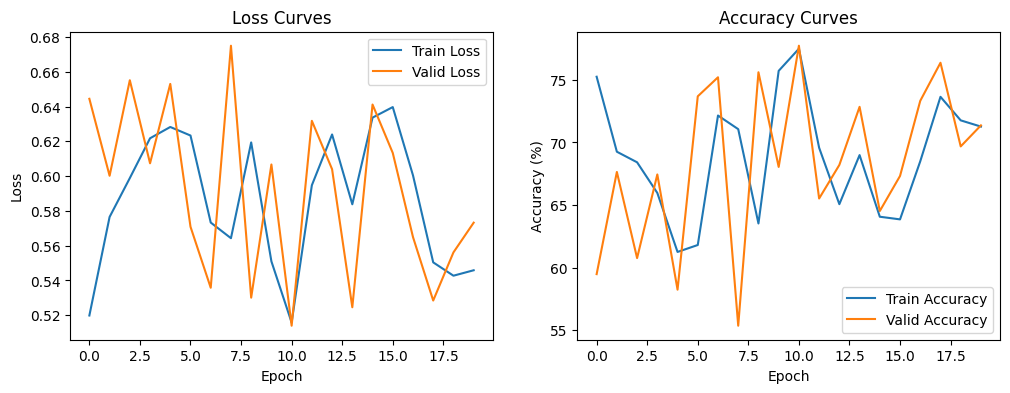

In [47]:
# Implement the training loop
train_losses, valid_losses, train_accuracies, valid_accuracies = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

### RNN from Scratch
Implement an RNN from scratch by creating a custom RNN cell and a model that stacks these cells over time.

In [48]:
class CustomRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomRNNCell, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.tanh = nn.Tanh()

    def forward(self, input, hidden):
        hidden = self.tanh(self.i2h(input) + self.h2h(hidden))
        return hidden


In [49]:
class CustomRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token2idx['<PAD>'])
        self.rnn_cell = CustomRNNCell(embedding_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.2)

    def forward(self, inputs):
        embedded = self.embedding(inputs)
        batch_size = embedded.size(0)
        hidden = torch.zeros(batch_size, self.hidden_size).to(embedded.device)
        
        for t in range(embedded.size(1)):
            hidden = self.rnn_cell(embedded[:, t, :], hidden)
        
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out #probabilities for each class in the output.


### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

In [55]:
custom_model = CustomRNN(vocab_size, 100, hidden_size, output_size)
custom_model = custom_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=0.0005)

Epoch 1/15 - Validation: 100%|██████████| 10/10 [00:00<00:00, 48.67it/s]


Epoch 1/15
  Train Loss: 0.6255, Train Acc: 64.53%
  Valid Loss: 0.6674, Valid Acc: 59.92%


Epoch 2/15 - Validation: 100%|██████████| 10/10 [00:00<00:00, 54.87it/s]


Epoch 2/15
  Train Loss: 0.6666, Train Acc: 59.50%
  Valid Loss: 0.6634, Valid Acc: 61.04%


Epoch 3/15 - Validation: 100%|██████████| 10/10 [00:00<00:00, 58.84it/s]


...

Epoch 13/15
  Train Loss: 0.5340, Train Acc: 75.46%
  Valid Loss: 0.5571, Valid Acc: 74.60%


Epoch 14/15 - Validation: 100%|██████████| 10/10 [00:00<00:00, 37.25it/s]


Epoch 14/15
  Train Loss: 0.5488, Train Acc: 74.62%
  Valid Loss: 0.6857, Valid Acc: 68.08%


Epoch 15/15 - Validation: 100%|██████████| 10/10 [00:00<00:00, 54.71it/s]


Epoch 15/15
  Train Loss: 0.5642, Train Acc: 73.00%
  Valid Loss: 0.5834, Valid Acc: 73.64%


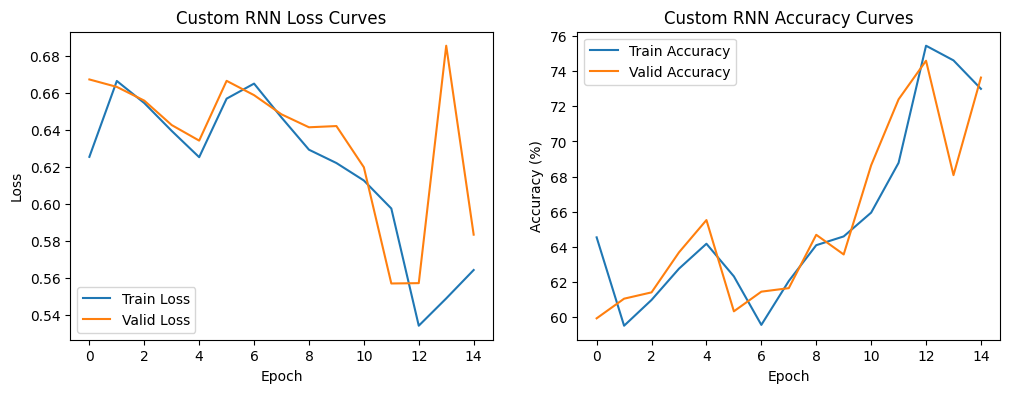

In [59]:
train_losses_custom, valid_losses_custom, train_accuracies_custom, valid_accuracies_custom = train_model(
    custom_model, train_loader, valid_loader, criterion, optimizer, epochs=15
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_custom, label='Train Loss')
plt.plot(valid_losses_custom, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Custom RNN Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_custom, label='Train Accuracy')
plt.plot(valid_accuracies_custom, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Custom RNN Accuracy Curves')
plt.show()

### evaluate RNN models on test set
To complete evaluate_on_test, loop through the test data to get predictions, calculate accuracy, and print a classification report for model evaluation. This function can be used to evaluate the performance LSTM models too.

**NOTE : to earn full marks for this section, you must adjust the network's hyperparameters so that each rnn models achieves at least 70% accuracy on the test data. If you achieve less than the required accuracy, consider adjusting your training loop and hyperparameters, such as the hidden state size and learning rate, to improve model performance.**

In [60]:
# Evaluate on test data
def evaluate_on_test(model, test_loader):
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    accuracy = 100 * np.sum(np.array(all_predictions) == np.array(all_targets)) / len(all_targets)
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(classification_report(all_targets, all_predictions, target_names=['Negative', 'Positive']))

In [61]:
# Evaluate both RNN models on the test dataset
print("=" * 50)
print("Evaluating RNN Classifier (nn.RNN)")
print("=" * 50)
evaluate_on_test(model, test_loader)

print("\n" + "=" * 50)
print("Evaluating Custom RNN Classifier")
print("=" * 50)
evaluate_on_test(custom_model, test_loader)

Evaluating RNN Classifier (nn.RNN)
Test Accuracy: 69.92%
              precision    recall  f1-score   support

    Negative       0.79      0.54      0.64      1250
    Positive       0.65      0.86      0.74      1250

    accuracy                           0.70      2500
   macro avg       0.72      0.70      0.69      2500
weighted avg       0.72      0.70      0.69      2500


Evaluating Custom RNN Classifier
Test Accuracy: 73.40%
              precision    recall  f1-score   support

    Negative       0.68      0.88      0.77      1250
    Positive       0.84      0.58      0.69      1250

    accuracy                           0.73      2500
   macro avg       0.76      0.73      0.73      2500
weighted avg       0.76      0.73      0.73      2500



# LSTM section

### LSTM with nn.LSTM
Define an LSTM model using PyTorch's built-in nn.LSTM.

In [30]:
class LSTMClassifier(nn.Module):
    def __init__(self, output_size, hidden_size, vocab_size,
                 device, bidirectional=False, n_layers=1,
                 embedding_dimension=50):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.device = device

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dimension, padding_idx = token2idx['<PAD>'])

        self.lstm = nn.LSTM(embedding_dimension, hidden_size, n_layers, 
                           batch_first=True, bidirectional=bidirectional)
        
        lstm_output_size = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Linear(lstm_output_size, output_size)
        self.dropout = nn.Dropout(0.2)

    def forward(self, inputs):
        # Initialize hidden state and cell state with zeros
        hidden = torch.zeros(self.n_layers, inputs.size(0), self.hidden_size).to(inputs.device)
        cell_state = torch.zeros(self.n_layers, inputs.size(0), self.hidden_size).to(inputs.device)

        embedded = self.embedding(inputs)
        lstm_out, (hidden, cell_state) = self.lstm(embedded, (hidden, cell_state))
        
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        
        return out  # probabilities for each class in the output.

### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

**Note**: You are not allowed to use library-built trainer functions in this section; the training loop should be implemented manually.

**Note**: To implement the training loop, you have the option to create a single train_model function that trains a model over multiple epochs, calculates training and validation accuracy, and logs the losses. Once written, this function can be reused for all RNN and LSTM models, allowing you to simply call it with different model instances for training. Reusing the function in this way will ensure that you receive credit for the training section of each subsequent model without needing to write separate loops , with just the correct function call.

In [31]:
lstm_model = LSTMClassifier(output_size, hidden_size, vocab_size, device, 
                            bidirectional=False, n_layers=2, embedding_dimension=100)
lstm_model = lstm_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

Epoch 1/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 88.01it/s]


Epoch 1/20
  Train Loss: 0.6535, Train Acc: 60.67%
  Valid Loss: 0.6380, Valid Acc: 65.60%


Epoch 2/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 91.15it/s]


Epoch 2/20
  Train Loss: 0.6445, Train Acc: 63.37%
  Valid Loss: 0.6816, Valid Acc: 55.24%


Epoch 3/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 77.98it/s]


...

Epoch 18/20
  Train Loss: 0.0738, Train Acc: 97.74%
  Valid Loss: 0.5796, Valid Acc: 85.84%


Epoch 19/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 73.53it/s]


Epoch 19/20
  Train Loss: 0.0564, Train Acc: 98.48%
  Valid Loss: 0.5753, Valid Acc: 85.68%


Epoch 20/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 87.72it/s]


Epoch 20/20
  Train Loss: 0.0490, Train Acc: 98.68%
  Valid Loss: 0.6419, Valid Acc: 86.00%


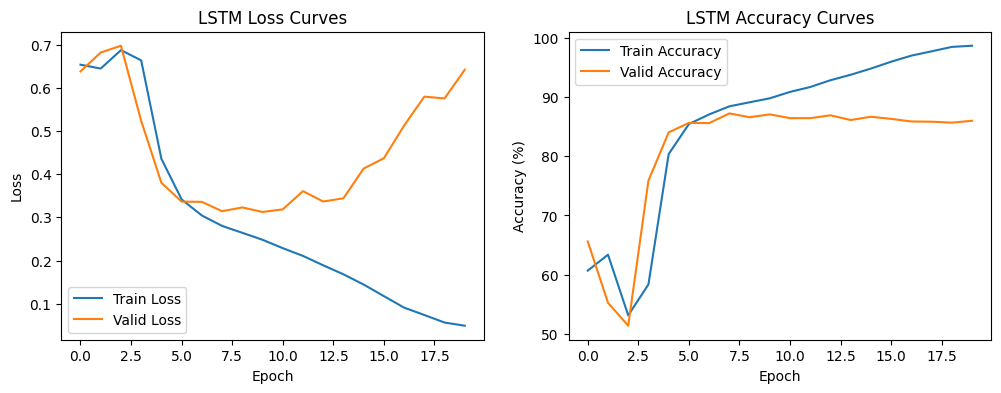

In [32]:
train_losses_lstm, valid_losses_lstm, train_accuracies_lstm, valid_accuracies_lstm = train_model(lstm_model, train_loader, valid_loader, criterion, optimizer, epochs=20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_lstm, label='Train Loss')
plt.plot(valid_losses_lstm, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_lstm, label='Train Accuracy')
plt.plot(valid_accuracies_lstm, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('LSTM Accuracy Curves')
plt.show()


### Custom LSTM from Scratch
Implement an LSTM from scratch by defining a LSTM cell and a model that combines these cells over the sequence.

In [33]:
class CustomLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.combined = nn.Linear(input_size + hidden_size, 4 * hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, input, hidden, cell_state):
        combined = torch.cat((input, hidden), dim=1)
        gates = self.combined(combined)
        
        i_gate, f_gate, c_gate, o_gate = gates.chunk(4, dim=1)
        
        i_gate = self.sigmoid(i_gate)
        f_gate = self.sigmoid(f_gate)
        c_gate = self.tanh(c_gate)
        o_gate = self.sigmoid(o_gate)
        
        cell_state = f_gate * cell_state + i_gate * c_gate
        hidden = o_gate * self.tanh(cell_state)
        
        return hidden, cell_state # New hidden state , New cell state


In [34]:
class CustomLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(CustomLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token2idx['<PAD>'])
        self.lstm_cell = CustomLSTMCell(embedding_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.2)

    def forward(self, inputs):
        # Initialize hidden state and cell state with zeros
        hidden = torch.zeros(inputs.size(0), self.hidden_size).to(inputs.device)
        cell_state = torch.zeros(inputs.size(0), self.hidden_size).to(inputs.device)
        embedded = self.embedding(inputs)
        
        for t in range(embedded.size(1)):
            hidden, cell_state = self.lstm_cell(embedded[:, t, :], hidden, cell_state)
        
        hidden = self.dropout(hidden)
        out = self.fc(hidden)

        return out  # probabilities for each class in the output.


### Train model

In this section, you should train model for multiple epochs on the training data and evaluate it on the validation data after each epoch, reporting the model's accuracy. Ensure that the model is set to train mode during training and switched to eval mode for evaluation on the validation data. The objective is to implement the training loop and, at the next , compute and report the final accuracy on the test data.

In [35]:
custom_lstm_model = CustomLSTM(vocab_size, embedding_dim, hidden_size, output_size)
custom_lstm_model = custom_lstm_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_lstm_model.parameters(), lr=0.001)

Epoch 1/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 26.78it/s]


Epoch 1/20
  Train Loss: 0.5967, Train Acc: 66.59%
  Valid Loss: 0.4597, Valid Acc: 78.16%


Epoch 2/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 26.73it/s]


Epoch 2/20
  Train Loss: 0.4162, Train Acc: 81.69%
  Valid Loss: 0.3720, Valid Acc: 83.44%


Epoch 3/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 19.99it/s]


...

Epoch 18/20
  Train Loss: 0.0429, Train Acc: 98.94%
  Valid Loss: 0.5635, Valid Acc: 87.36%


Epoch 19/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 18.58it/s]


Epoch 19/20
  Train Loss: 0.0403, Train Acc: 99.00%
  Valid Loss: 0.6375, Valid Acc: 85.40%


Epoch 20/20 - Validation: 100%|██████████| 10/10 [00:00<00:00, 18.06it/s]


Epoch 20/20
  Train Loss: 0.0460, Train Acc: 98.76%
  Valid Loss: 0.5917, Valid Acc: 86.56%


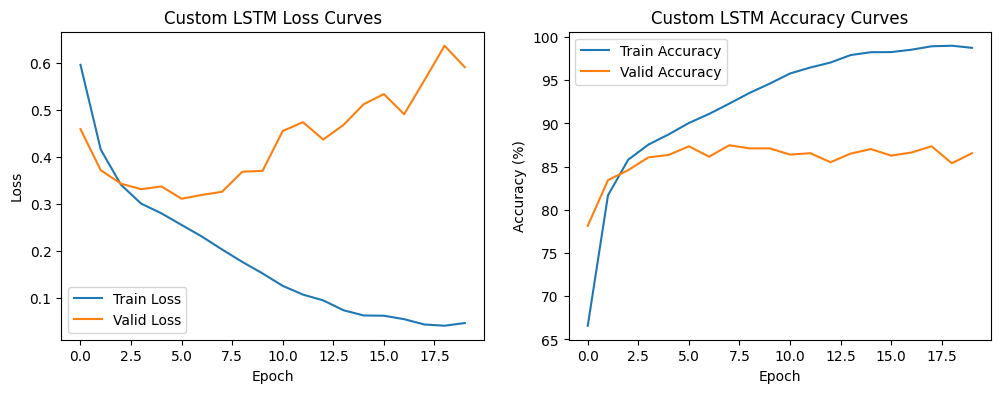

In [36]:
train_losses_custom_lstm, valid_losses_custom_lstm, train_accuracies_custom_lstm, valid_accuracies_custom_lstm = train_model(custom_lstm_model, train_loader, valid_loader, criterion, optimizer, epochs=20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_custom_lstm, label='Train Loss')
plt.plot(valid_losses_custom_lstm, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Custom LSTM Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_custom_lstm, label='Train Accuracy')
plt.plot(valid_accuracies_custom_lstm, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Custom LSTM Accuracy Curves')
plt.show()

### evaluate LSTM models on test set
To complete evaluate_on_test, loop through the test data to get predictions, calculate accuracy, and print a classification report for model evaluation.
you can use the `evaluate_on_test` function implemented in the previous section. Alternatively, you may write a new function to conduct this evaluation.ensure report the "classification_report" of both LSTM models.

**NOTE : to earn full marks for this section, you must adjust the network's hyperparameters so that each lstm models achieves at least 80% accuracy on the test data. If you achieve less than the required accuracy, consider adjusting your training loop and hyperparameters, such as the hidden state size and learning rate, to improve model performance.**

In [37]:
# Evaluate both LSTM models on the test dataset
evaluate_on_test(lstm_model, test_loader)
evaluate_on_test(custom_lstm_model, test_loader)

Test Accuracy: 84.48%
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      1250
    Positive       0.85      0.84      0.84      1250

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500

Test Accuracy: 85.16%
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85      1250
    Positive       0.86      0.84      0.85      1250

    accuracy                           0.85      2500
   macro avg       0.85      0.85      0.85      2500
weighted avg       0.85      0.85      0.85      2500



# Testing RNN and LSTM Models on a New Review

In [62]:
# Example review
review = "It is no wonder that the film has such a high rating, it is quite literally breathtaking. What can I say that hasn't said before? Not much, it's the story, the acting, the premise, but most of all, this movie is about how it makes you feel. Sometimes you watch a film, and can't remember it days later, this film loves with you, once you've seen it, you don't forget."


## Preprocess the test Review
To prepare the review for the model, we need to follow similar preprocessing steps as we did for the dataset:

Remove special characters and convert the text to lowercase.
Tokenize the text into individual words.
Remove stopwords to focus only on meaningful words.
Convert tokens to indices based on the token2idx dictionary created earlier.
Pad or truncate the sequence to a length of max_len .


In [63]:
import torch
import re
from nltk import wordpunct_tokenize
from nltk.corpus import stopwords


# Preprocessing function
def preprocess_text(text, stop_words, token2idx, max_len):

    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()

    tokens = wordpunct_tokenize(text)

    tokens = [token for token in tokens if token not in stop_words]

    unk_idx = token2idx.get('<UNK>', 0)
    tokens_idx = [token2idx.get(token, unk_idx) for token in tokens]

    if len(tokens_idx) > max_len:
        tokens_idx = tokens_idx[:max_len]
    else:
        tokens_idx = tokens_idx + [token2idx['<PAD>']] * (max_len - len(tokens_idx))

    return tokens_idx  # Return the processed list of indices

# Get stopwords
stop_words = set(stopwords.words('english'))

# Preprocess the review
review_indices = preprocess_text(review, stop_words, token2idx, max_len)

# Convert the indices to a tensor and move it to the device (GPU or CPU)
input_tensor = torch.LongTensor([review_indices]).to(device)

## Make Predictions
Now that we have preprocessed the review, use both the RNN and LSTM models to make predictions on the sentiment of the review.

Set the model to evaluation mode to prevent updates during inference.
Predict the sentiment class by passing the input_tensor to the model.
Interpret the prediction as either "Positive" or "Negative" based on the model's output.

In [66]:
def predict_sentiment(model, input_tensor, model_name="Model"):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        class_label = "Positive" if predicted.item() == 1 else "Negative"

    print(f"The predicted class for the review by {model_name} is: {class_label}")

In [67]:
# Make predictions using with "predict_sentiment" function for each of four models above
predict_sentiment(model, input_tensor, "RNN Classifier (nn.RNN)")
predict_sentiment(custom_model, input_tensor, "Custom RNN")
predict_sentiment(lstm_model, input_tensor, "LSTM Classifier (nn.LSTM)")
predict_sentiment(custom_lstm_model, input_tensor, "Custom LSTM")

The predicted class for the review by RNN Classifier (nn.RNN) is: Positive
The predicted class for the review by Custom RNN is: Negative
The predicted class for the review by LSTM Classifier (nn.LSTM) is: Positive
The predicted class for the review by Custom LSTM is: Positive


# Questions

[1] - Based on your observations, what do you think caused the difference in performance between the RNN and LSTM models (on test set)? Analyze this difference using the results from the notebook, and discuss where a simple RNN might perform better.

LSTM models achieved 84-85% accuracy while RNN models only reached 70-73% accuracy that this difference is caused by the vanishing gradient problem and RNNs struggle to learn long term dependencies over 100 token sequences because gradients diminish as they backpropagate through time and LSTMs solve this with gates that allow them to selectively remember relevant information over longer periods and the training curves in the notebook confirm that LSTMs learn more stably while RNNs fluctuate and a simple RNN might perform better only on very short sequences under 20 tokens when training speed is prioritized or on very small datasets where LSTMs would overfit

[2] - If we increase max_len in the preprocessing step to 300, what changes in models (rnn & lstm ) performance would you expect, and why? Please *explain* and discuss the impact this may have on the learning process and the final results.

Increasing the maximum sequence length to 300 would harm RNN performance significantly due to even worse vanishing gradients but LSTMs might see a small improvement for very long reviews but at a high computational cost and training time and memory usage would roughly triple for both models and longer sequences also introduce more noise because many IMDB reviews contain irrelevant information beyond 100 200 tokens and for RNNs accuracy would likely decrease but for LSTMs might hold steady or improve only slightly so the optimal sequence length for sentiment analysis on this dataset is typically between 100 and 200 tokens